# T04 — 2-D Stokes flow, and how to know it is right

**Cluster B — The numerical ladder.**

This is the notebook the whole suite turns on. Everything after it —
falling blocks, Rayleigh–Taylor instabilities, thermal convection, rifting — is
this solver plus a transport equation.

In the infinite-Prandtl limit that applies to the mantle, inertia is utterly
negligible and the momentum equation loses its time derivative:

$$\frac{\partial}{\partial x_j}\left(2\eta\,\dot\varepsilon_{ij}\right) - \frac{\partial P}{\partial x_i} + \rho g_i = 0, \qquad \frac{\partial v_i}{\partial x_i} = 0$$

The flow has no memory. It is determined *instantaneously* by the current
density and viscosity fields — which is why a geodynamic timestep is "solve
Stokes, then move things".

## Learning objectives

1. Explain why the unknowns sit on a **staggered grid** and what goes wrong if they do not.
2. Assemble the Stokes system as a sparse matrix and solve it.
3. **Verify** it against a manufactured solution and measure the convergence rate.
4. Recognise the two failure modes that produce plausible-looking nonsense: matrix scaling, and the hydrostatic cancellation.

## Prerequisites and runtime

* T00–T03. Some linear algebra.
* **Estimated runtime: about 1 minute.**

In [1]:
# === USER CONFIGURATION ===
RESOLUTIONS = (16, 24, 32, 48, 64)    # for the convergence study
DEMO_N = 64                            # resolution for the figures

In [2]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting
from geodynkit.stokes import (
    StokesGrid,
    manufactured_solution,
    solve_stokes,
    velocity_to_centres,
)

## 1. The staggered grid

The obvious thing to do is put velocity and pressure at the same points. The
obvious thing is wrong: that arrangement admits a **checkerboard pressure
mode** — a pressure field alternating cell by cell that the discrete gradient
operator cannot see, so it is invisible to the equations and free to grow to
any amplitude.

The standard cure is to stagger. Pressure at cell centres, the two velocity
components on the two sets of faces:

```
      vz(i,j)          vz at horizontal faces, shape (nz+1, nx)
    +----|----+
    |         |
 -- vx   P    vx --    vx at vertical faces, shape (nz, nx+1)
    |         |        P  at cell centres,    shape (nz, nx)
    +----|----+
```

Viscosity has to live in two places, because the two terms of the deviatoric
stress tensor are evaluated at different points: **normal** viscosity at cell
centres, **shear** viscosity at corners.

In [3]:
grid = StokesGrid(nx=DEMO_N, nz=DEMO_N, lx=1.0, lz=1.0)
print(grid)
print(f"  vx  {grid.n_vx:6d} unknowns")
print(f"  vz  {grid.n_vz:6d} unknowns")
print(f"  P   {grid.n_p:6d} unknowns")

StokesGrid(nx=64, nz=64, lx=1, lz=1, ndof=12416)
  vx    4160 unknowns
  vz    4160 unknowns
  P     4096 unknowns


## 2. Verification with a manufactured solution

Here is the method of manufactured solutions, which is the honest way to test a
PDE solver. Rather than looking for a problem you know the answer to, you
**choose** the answer and work out what forcing produces it.

Take a stream function $\psi = \sin(\pi x/L_x)\sin(\pi z/L_z)$ and set

$$v_x = \frac{\partial \psi}{\partial z}, \qquad v_z = -\frac{\partial \psi}{\partial x}$$

which is divergence-free by construction. Pick a pressure. Substitute into the
momentum equation and whatever is left over is the body force you need.

This particular stream function is chosen so the solution satisfies **free-slip
and impermeable conditions on all four walls**, so it tests the solver's real
boundary conditions rather than a special case built for the test.

In [4]:
exact = manufactured_solution(grid, eta=1.0)
eta = np.ones((DEMO_N, DEMO_N))
rho = np.zeros((DEMO_N, DEMO_N))

t0 = time.time()
vx, vz, p = solve_stokes(grid, eta, rho, gz=0.0,
                         fx_c=exact["fx"], fz_c=exact["fz"], bc="free-slip")
print(f"solved {grid.ndof} unknowns in {time.time() - t0:.2f} s")
print(f"max |vx - exact| = {np.abs(vx - exact['vx']).max():.3e}")

solved 12416 unknowns in 0.32 s
max |vx - exact| = 6.307e-04


One error is not a verification. **Refine and measure the rate.** A
second-order method must cut the error by four each time the grid doubles;
anything else means a bug, not bad luck.

In [5]:
print(f"{'n':>5} {'err(v)':>12} {'err(P)':>12} {'rate v':>7} {'rate P':>7} {'t (s)':>7}")
errs, prev = [], None
for n in RESOLUTIONS:
    g = StokesGrid(n, n, 1.0, 1.0)
    ex = manufactured_solution(g, eta=1.0)
    t0 = time.time()
    ux, uz, pp = solve_stokes(g, np.ones((n, n)), np.zeros((n, n)), gz=0.0,
                              fx_c=ex["fx"], fz_c=ex["fz"], bc="free-slip")
    dt = time.time() - t0
    ev = np.sqrt(np.mean((ux - ex["vx"]) ** 2) + np.mean((uz - ex["vz"]) ** 2))
    # pressure is defined only up to a constant, so compare after removing means
    ep = np.sqrt(np.mean(((pp - pp.mean()) - (ex["p"] - ex["p"].mean())) ** 2))
    rv = np.log(prev[0] / ev) / np.log(n / prev[2]) if prev else np.nan
    rp = np.log(prev[1] / ep) / np.log(n / prev[2]) if prev else np.nan
    print(f"{n:5d} {ev:12.4e} {ep:12.4e} {rv:7.2f} {rp:7.2f} {dt:7.2f}")
    errs.append((n, ev, ep))
    prev = (ev, ep, n)

    n       err(v)       err(P)  rate v  rate P   t (s)
   16   6.9372e-03   8.0409e-04     nan     nan    0.01
   24   3.1106e-03   3.5715e-04    1.98    2.00    0.02
   32   1.7578e-03   2.0085e-04    1.98    2.00    0.03
   48   7.8503e-04   8.9255e-05    1.99    2.00    0.07


   64   4.4267e-04   5.0203e-05    1.99    2.00    0.15


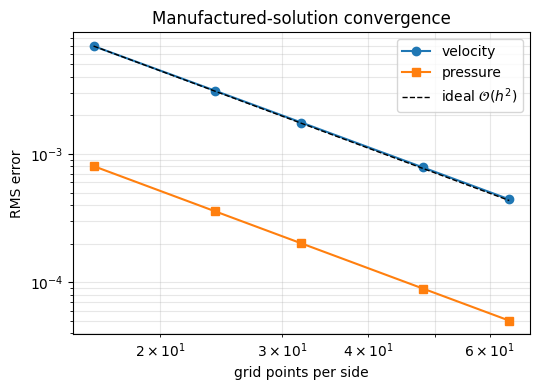

In [6]:
ns = np.array([e[0] for e in errs], float)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(ns, [e[1] for e in errs], "o-", label="velocity")
ax.loglog(ns, [e[2] for e in errs], "s-", label="pressure")
ax.loglog(ns, errs[0][1] * (ns / ns[0]) ** -2.0, "k--", lw=1,
          label=r"ideal $\mathcal{O}(h^2)$")
ax.set(xlabel="grid points per side", ylabel="RMS error",
       title="Manufactured-solution convergence")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

Both curves sit on the reference slope. **The solver is second order in
velocity and in pressure**, which is what this discretisation should deliver.

## 3. The two ways to get plausible nonsense

### Matrix scaling

In SI units, viscous coefficients are of order $\eta/h^2 \approx 10^{13}$ while
pressure-gradient coefficients are of order $1/h \approx 10^{-4}$. Seventeen
orders of magnitude in one matrix defeats a direct sparse solve, and what comes
back is not an error message — it is a velocity field of a few centimetres per
year that looks entirely reasonable.

`solve_stokes` handles this in two stages: a **column scaling** that makes the
pressure unknown dimensionally comparable to the velocities, and a **row
equilibration** that divides each row by its largest entry. Scaling by equation
*type* instead is the tempting shortcut, and it is wrong — it rescales the
pinned boundary rows along with the physical ones and destroys the very
conditioning it was meant to buy.

### The hydrostatic cancellation

Here is the test that catches it. Uniform density, uniform viscosity, rigid
walls: the exact answer is **no flow at all**. The pressure gradient must cancel
gravity to about ten significant figures, and whatever survives that
cancellation is spurious flow.

In [7]:
n = 48
g = StokesGrid(n, n, 500e3, 500e3)
ux, uz, pp = solve_stokes(g, np.full((n, n), 1e21), np.full((n, n), 3300.0), gz=9.81)
cm_yr = 365.25 * 24 * 3600 * 100
print(f"spurious velocity: {max(np.abs(ux).max(), np.abs(uz).max()) * cm_yr:.3e} cm/yr")
print(f"pressure at base:  {pp[-1].mean() / 1e9:.3f} GPa  "
      f"(hydrostatic: {3300 * 9.81 * 500e3 / 1e9:.3f} GPa)")
print("\nIf that first number were ~1 cm/yr instead of ~1e-14, every subsequent")
print("figure in this suite would look fine and be wrong.")

spurious velocity: 2.120e-14 cm/yr
pressure at base:  15.849 GPa  (hydrostatic: 16.186 GPa)

If that first number were ~1 cm/yr instead of ~1e-14, every subsequent
figure in this suite would look fine and be wrong.


## 4. Looking at the solution

Now plot the manufactured velocity field with the T00 idioms. Because this is a
unit box rather than a depth section, we turn off the axis flip.

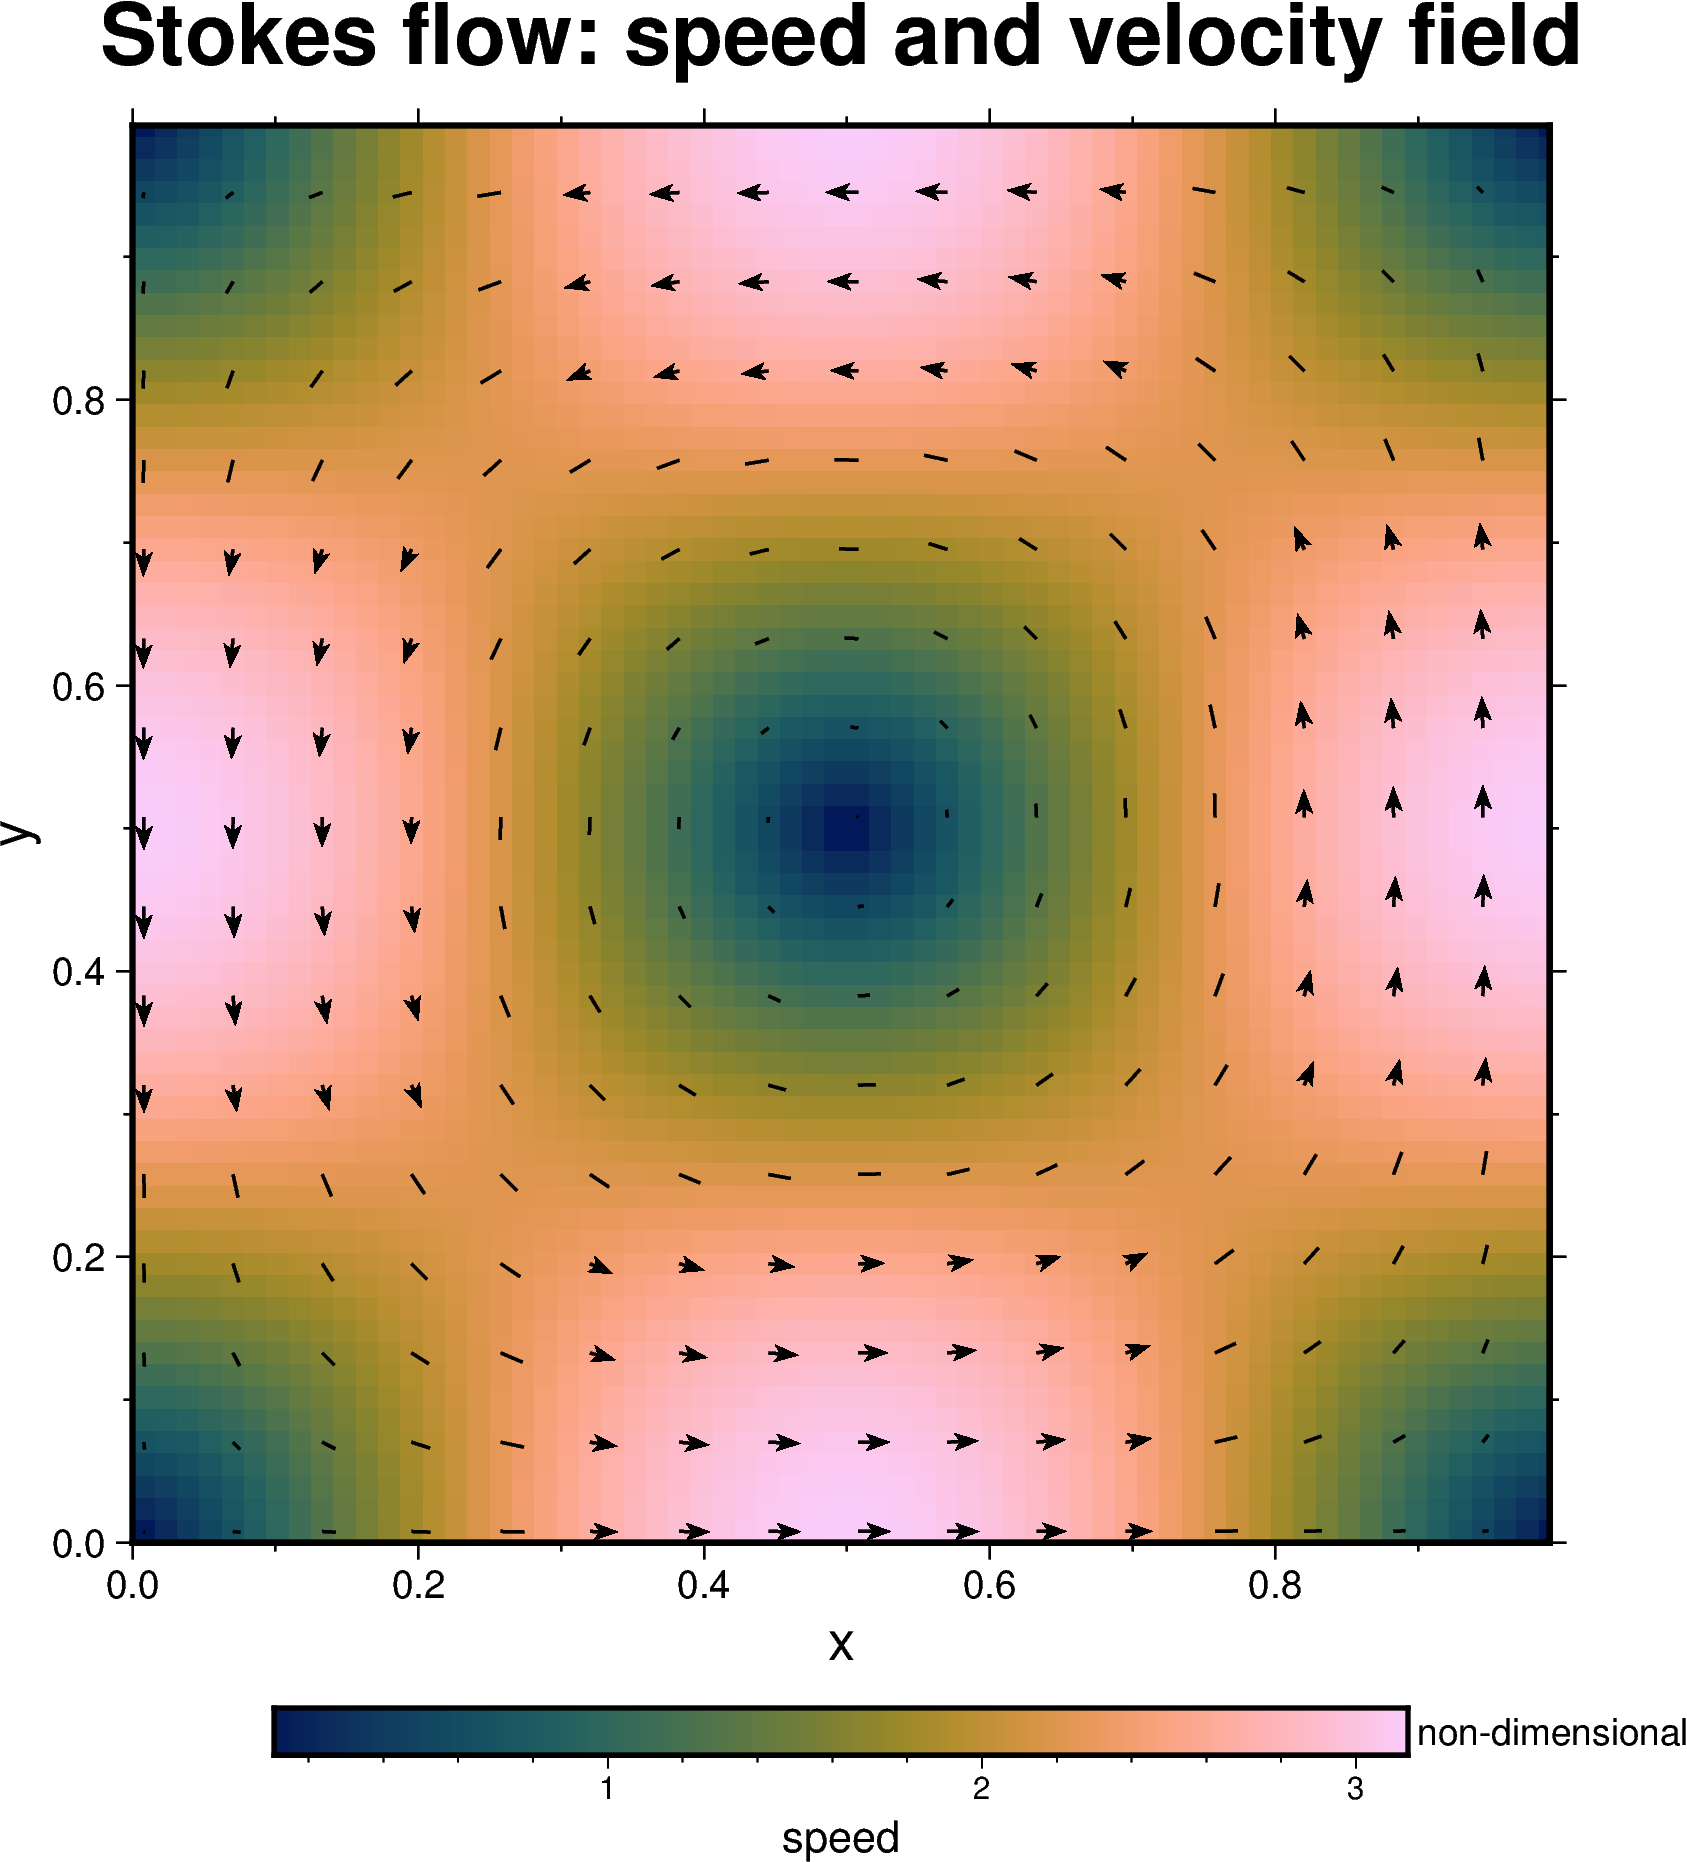

In [8]:
vxc, vzc = velocity_to_centres(grid, vx, vz)
speed = np.hypot(vxc, vzc)

fig = plotting.field_panel(
    speed, grid.xc, grid.zc,
    kind="velocity", title="Stokes flow: speed and velocity field",
    label="speed", unit="non-dimensional",
    vx=vxc, vz=vzc, every=4,
    xlabel="x", ylabel="y", depth_down=False, width_cm=12.0,
)
fig.show()

## Extend this

* Time the solve as a function of `n`. The direct sparse solve scales roughly as
  $\mathcal{O}(n^3)$ in 2-D — at what resolution does that become the bottleneck,
  and what would you reach for instead?
* Switch `bc="no-slip"` and watch the boundary layers appear. Does the
  manufactured solution still converge at second order? Why not?
* Give the viscosity a jump of $10^6$ across the middle of the box and inspect
  the pressure field. This is the SolCx benchmark in miniature.

**Next:** T05 puts material on Lagrangian markers so compositional interfaces
survive large finite strain, and drops a dense block through the box.